In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
import torch.nn as nn
import pickle
from PIL import Image
from scipy.signal import convolve2d
from numba import njit

In [2]:
def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

# Chargement des 5 batches d'entraînement et du batch de test
data_batch_1 = unpickle("./data/CIFAR-10/data_batch_1")
data_batch_2 = unpickle("./data/CIFAR-10/data_batch_2")
data_batch_3 = unpickle("./data/CIFAR-10/data_batch_3")
data_batch_4 = unpickle("./data/CIFAR-10/data_batch_4")
data_batch_5 = unpickle("./data/CIFAR-10/data_batch_5")
test_batch = unpickle("./data/CIFAR-10/test_batch")

# Fusion des données pour l'entraînement
x_train = np.concatenate((data_batch_1[b'data'], data_batch_2[b'data'], data_batch_3[b'data'], data_batch_4[b'data'], data_batch_5[b'data']), axis=0)
y_train = np.concatenate((data_batch_1[b'labels'], data_batch_2[b'labels'], data_batch_3[b'labels'], data_batch_4[b'labels'], data_batch_5[b'labels']), axis=0)
x_test = test_batch[b'data']
y_test = np.array(test_batch[b'labels'])
labels = ["avion", "automobile", "oiseau", "chat", "cerf", "chien", "grenouille", "cheval", "bateau", "camion"]

(399, 532)
[[26 25 25 ...  1  1  1]
 [50 42 39 ...  1  1  1]
 [70 66 64 ...  1  1  1]
 ...
 [81 82 83 ... 83 83 82]
 [80 80 81 ... 83 82 82]
 [79 79 80 ... 83 82 81]]


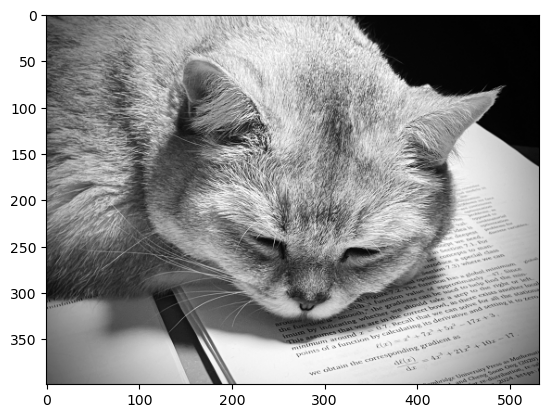

In [3]:
img = Image.open("img_cat.png").convert('L')
img_array = np.asarray(img)
print(img_array.shape)
print(img_array)
plt.imshow(img_array, cmap='gray')

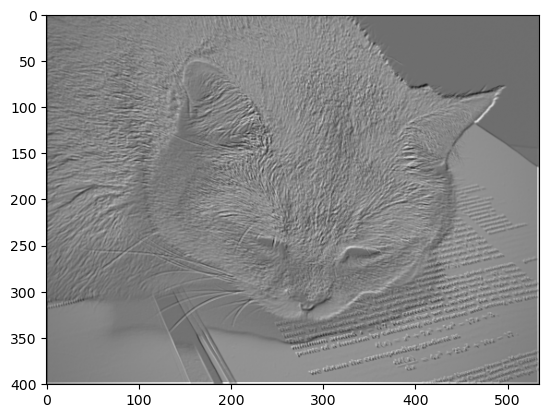

In [4]:
K = np.array([[1, 1, 1],
                       [1, 1, 1],
                       [1, 1, 1]])/9

K2 = np.array([[0, -1, 0],
                       [-1, 5, -1],
                       [0, -1, 0]])

K3 = np.array([[-1, 2, -1],
                       [-1, 2, -1],
                       [-1, 2, -1]])

K4 = np.array([[-1, 0, 1],
                       [-1, 0, 1],
                       [-1, 0, 1]])

K5 = np.array([[-1, 0, 1],
                       [-2, 0, 2],
                       [-1, 0, 1]])

K6 = np.array([[-2, -1, 0],
                       [-1, 1, 1],
                       [0, 1, 2]])

m = convolve2d(img_array, K6, fillvalue=0)

plt.imshow(m, cmap='gray')

In [5]:
def add_0_padding(image):
    #Ajoute une bordure de 1 pixel de zéros autour de l'image.
    image = np.hstack((image, np.zeros((image.shape[0], 1))))
    image = np.hstack((np.zeros((image.shape[0], 1)), image))
    image = np.vstack((image, np.zeros((1, image.shape[1]))))
    image = np.vstack((np.zeros((1, image.shape[1])), image))
    return image

In [6]:
def convolution2d(image, kernel, bias=0):
    #Applique une convolution 2D 
    padded_image = add_0_padding(image)
    convolve_image = np.zeros(image.shape)
    kernel = np.flipud(np.fliplr(kernel))
    for i in range(1, padded_image.shape[0]-1):
        for j in range(1, padded_image.shape[1]-1):
            n = kernel.shape[0]//2
            m = kernel.shape[1]//2
            convolve_image[i-1, j-1] = np.sum(padded_image[i-n:i+n+1, j-m:j+m+1] * kernel) + bias
    return convolve_image

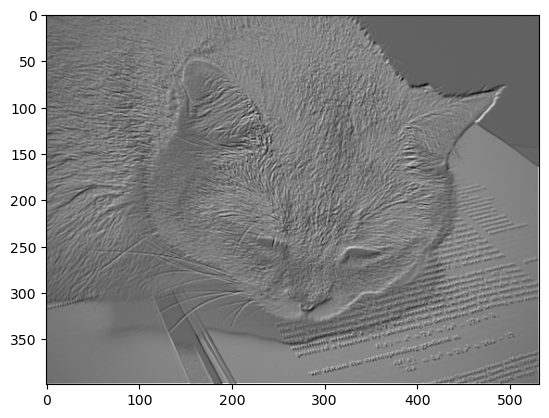

In [7]:
plt.imshow(convolution2d(img_array, K6), cmap='gray')

In [8]:
def convolution3d(image, kernel, bias=0):
    #Convolution sur plusieurs canaux (comme RGB), et retourne une seule carte 2D
    H, W, C = image.shape
    kh, kw, Ck = kernel.shape
    assert C == Ck

    out = np.zeros((H, W), dtype=np.float32)
    for c in range(C):
        out += convolution2d(image[:, :, c], kernel[:, :, c])
    out += bias
    return out

In [9]:
def convolution2d_RGB(image, kernel, bias=0):
    #Applique une convolution indépendante sur chaque canal de couleur
    convolve_image = np.zeros(image.shape)
    for c in range(image.shape[2]):
        convolve_image[:, :, c] = convolution2d(image[:, :, c], kernel[:, :, c], bias=bias)
    return convolve_image

In [10]:
def do_convolution_RGB():
    #Charge une image couleur et lui applique le filtre K6 sur chaque canal.
    img_rgb = Image.open("img_cat.png").convert('RGB')
    img_array_rgb = np.asarray(img_rgb)
    K_rgb = np.stack((K6, K6, K6), axis=2)
    convolved_rgb = convolution2d_RGB(img_array_rgb, K_rgb).clip(0, 255).astype(np.uint8)
    return convolved_rgb

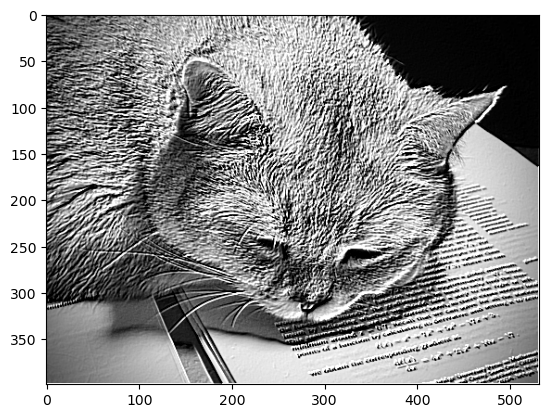

In [11]:
convolved_rgb = do_convolution_RGB()
plt.imshow(convolved_rgb, cmap='gray')

In [12]:
def max_pooling(image, size=2, stride=2):
    #Réduit la taille de l'image en ne gardant que le maximum local.
    pooled_image = np.zeros((image.shape[0]//size, image.shape[1]//size))
    for i in range(0, image.shape[0]-size+1, int(stride)):
        for j in range(0, image.shape[1]-size+1, stride):
            pooled_image[i//size, j//size] = np.max(image[i:i+size, j:j+size])
    return pooled_image

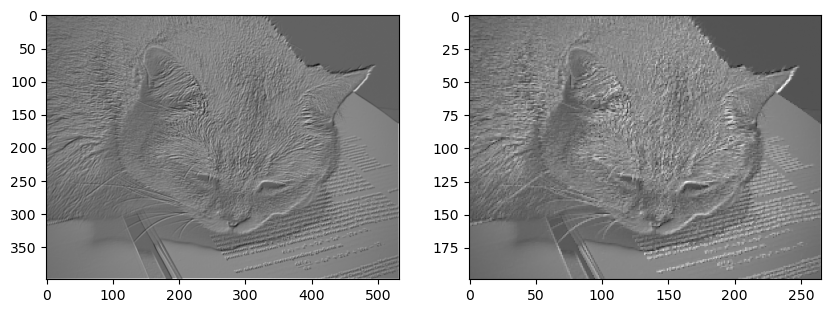

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
convolved = convolution2d(img_array, K6)
maxpooled = max_pooling(convolved, size=2, stride=2)
axs[0].imshow(convolution2d(img_array, K6), cmap='gray')
axs[1].imshow(max_pooling(convolution2d(img_array, K6), size=2, stride=2), cmap='gray')

" print(filters_2d.shape)\nconvolved_images_batch = conv3d_batch(test_0, filters_2d)\nconvolved_images_batch = np.transpose(convolved_images_batch, (1, 2, 0))  # (H, W, F)\nprint(convolved_images_batch.shape)\nconvolved_3d_images_batch = conv3d_batch(convolved_images_batch, filters_3d)\nconvolved_3d_images_batch = np.transpose(convolved_3d_images_batch, (1, 2, 0))  # (H, W, F)\nprint(convolved_3d_images_batch.shape)\nmaxpooled_3d_images_batch = np.zeros((convolved_3d_images_batch.shape[0]//2, convolved_3d_images_batch.shape[1]//2, convolved_3d_images_batch.shape[2]))\nfor i in range(convolved_3d_images_batch.shape[2]):\n    maxpooled_3d_images_batch[:, :, i] = max_pooling(convolved_3d_images_batch[:, :, i], size=2, stride=2)\nprint(maxpooled_3d_images_batch.shape)\nconvolved_3d_images_batch_2 = conv3d_batch(maxpooled_3d_images_batch, filters_3d_2)\nconvolved_3d_images_batch_2 = np.transpose(convolved_3d_images_batch_2, (1, 2, 0))  # (H, W, F)\nprint(convolved_3d_images_batch_2.shape)\n

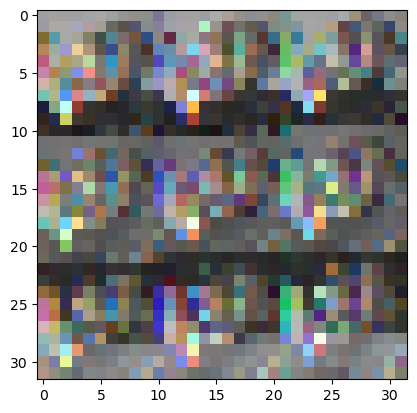

In [14]:
img_rgb = Image.open("img_cat.png").convert('RGB')
img_array_rgb = np.asarray(img_rgb)

test_0 = x_test[0].reshape(32, 32, 3)
plt.imshow(test_0)

""" print(filters_2d.shape)
convolved_images_batch = conv3d_batch(test_0, filters_2d)
convolved_images_batch = np.transpose(convolved_images_batch, (1, 2, 0))  # (H, W, F)
print(convolved_images_batch.shape)
convolved_3d_images_batch = conv3d_batch(convolved_images_batch, filters_3d)
convolved_3d_images_batch = np.transpose(convolved_3d_images_batch, (1, 2, 0))  # (H, W, F)
print(convolved_3d_images_batch.shape)
maxpooled_3d_images_batch = np.zeros((convolved_3d_images_batch.shape[0]//2, convolved_3d_images_batch.shape[1]//2, convolved_3d_images_batch.shape[2]))
for i in range(convolved_3d_images_batch.shape[2]):
    maxpooled_3d_images_batch[:, :, i] = max_pooling(convolved_3d_images_batch[:, :, i], size=2, stride=2)
print(maxpooled_3d_images_batch.shape)
convolved_3d_images_batch_2 = conv3d_batch(maxpooled_3d_images_batch, filters_3d_2)
convolved_3d_images_batch_2 = np.transpose(convolved_3d_images_batch_2, (1, 2, 0))  # (H, W, F)
print(convolved_3d_images_batch_2.shape)
maxpooled_3d_images_batch_2 = np.zeros((convolved_3d_images_batch_2.shape[0]//2, convolved_3d_images_batch_2.shape[1]//2, convolved_3d_images_batch_2.shape[2]))
for i in range(convolved_3d_images_batch_2.shape[2]):
    maxpooled_3d_images_batch_2[:, :, i] = max_pooling(convolved_3d_images_batch_2[:, :, i], size=2, stride=2)
print(maxpooled_3d_images_batch_2.shape)
plt.imshow(maxpooled_3d_images_batch_2[:, :, 0], cmap='gray') """

In [17]:
def softmax(x):
    #Calcule les probabilités de sortie
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum()

3


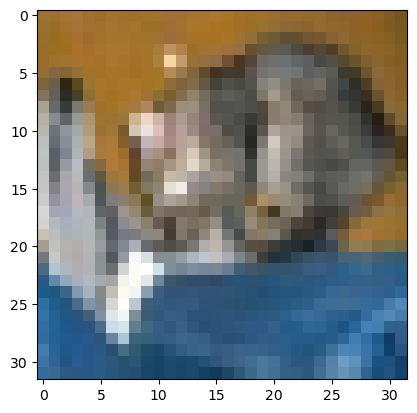

In [18]:
@njit
def dense_softmax_forward(flatten_res, A, B, y_true):
    Z = flatten_res @ A + B          # (10,)
    Z_shift = Z - np.max(Z)
    exp_Z = np.exp(Z_shift)
    probs = exp_Z / np.sum(exp_Z)    # (10,)
    loss = -np.log(probs[y_true] + 1e-15)  # Cross-entropy loss
    cache = (flatten_res, A, B, Z, probs, y_true)
    return loss, probs, cache

""" flatten_res = maxpooled_3d_images_batch_2.flatten()
A = np.random.rand(flatten_res.shape[0], 10)
B = np.random.rand(10)
Z = flatten_res @ A + B
y = np.argmax(softmax(Z))
print(labels[y])
print(labels[y_test[0]]) """
plt.imshow(x_test[0].reshape(3, 32, 32).transpose(1, 2, 0))
print(y_test[0])

In [19]:
@njit
def dense_softmax_backward(cache):
    flatten_res, A, B, Z, probs, y_true = cache
    dZ = probs.copy()
    dZ[y_true] -= 1  # (10,)

    # gradients paramètres
    dA = np.outer(flatten_res, dZ)  # (N, 10)
    dB = dZ  # (10,)

    # gradients entrée
    d_flatten = A @ dZ  # (N,)

    return d_flatten, dA, dB

In [20]:
def flatten_backward(d_flatten, shape):
    return d_flatten.reshape(shape)

In [21]:
def pad_image(image, padding):
    H, W, C = image.shape
    x_padded = np.zeros((H + 2*padding, W + 2*padding, C), dtype=image.dtype)
    x_padded[padding:padding+H, padding:padding+W, :] = image
    return x_padded

In [ ]:
def im2col(image, k=3):
    H, W, C = image.shape
    pad = k // 2
    padded = pad_image(image, pad)
    cols = np.zeros((H * W, k * k * C), dtype=np.float32)
    idx = 0
    for i in range(H):
        for j in range(W):
            patch = padded[i:i+k, j:j+k, :].reshape(-1)
            cols[idx] = patch
            idx += 1
    return cols  # (H*W, 9*C)

In [ ]:
def conv3d_batch(image, filters, bias=None):
    H, W, C = image.shape
    F, kh, kw, Ck = filters.shape
    assert C == Ck

    X_col = im2col(image, k=kh)           # (H*W, 9*C)
    W_mat = filters.reshape(F, -1)            # (F, 9*C)

    Y = W_mat @ X_col.T                       # (F, H*W)
    if bias is not None:
        Y += bias.reshape(F, 1)
    Y = Y.reshape(F, H, W)               # (F, H, W)
    return Y

In [ ]:
""" @njit
def max_pool2d_forward(x, size=2, stride=2):
    H, W = x.shape
    Hp, Wp = H // size, W // size
    out = np.zeros((Hp, Wp), dtype=np.float32)
    mask = np.zeros_like(x, dtype=bool)

    for i in range(Hp):
        for j in range(Wp):
            patch = x[i*stride:i*stride+size, j*stride:j*stride+size]
            max_val = np.max(patch)
            out[i, j] = max_val
            # masque du max
            u, v = np.unravel_index(np.argmax(patch), patch.shape)
            mask[i*stride+u, j*stride+v] = True

    return out, mask """

In [ ]:
@njit
def max_pool2d_forward(x, size=2, stride=2):
    H, W = x.shape
    Hp = (H - size) // stride + 1
    Wp = (W - size) // stride + 1

    out = np.zeros((Hp, Wp), dtype=np.float32)
    mask = np.zeros((H, W), dtype=np.bool_)

    for i in range(Hp):
        for j in range(Wp):
            i0 = i * stride
            j0 = j * stride

            max_val = x[i0, j0]
            max_u = 0
            max_v = 0

            for u in range(size):
                for v in range(size):
                    val = x[i0 + u, j0 + v]
                    if val > max_val:
                        max_val = val
                        max_u = u
                        max_v = v

            out[i, j] = max_val
            mask[i0 + max_u, j0 + max_v] = True

    return out, mask

In [ ]:
@njit
def max_pool2d_backward(dout, mask, size=2, stride=2):
    H, W = mask.shape
    Hp, Wp = dout.shape
    dx = np.zeros_like(mask, dtype=np.float32)

    for i in range(Hp):
        for j in range(Wp):
            # gradient ne va qu'à la position du max
            block_mask = mask[i*stride:i*stride+size, j*stride:j*stride+size]
            dx[i*stride:i*stride+size, j*stride:j*stride+size] += block_mask * dout[i, j]
    return dx

In [ ]:
def conv3d_backward_simple(dY, image, filters, padding=1):
    # dY : (F, H, W) = dL/ds
    H, W, C = image.shape
    F, kh, kw, Ck = filters.shape
    assert C == Ck

    # padding de l'entrée
    x_padded = pad_image(image, padding)
    dx_padded = np.zeros_like(x_padded, dtype=np.float32)
    dK = np.zeros_like(filters, dtype=np.float32)
    db = dY.sum(axis=(1, 2))   # (F,)

    for i in range(H):
        for j in range(W):
            patch = x_padded[i:i+kh, j:j+kw, :]  # (kh, kw, C)
            for f in range(F):
                grad_val = dY[f, i, j]
                # dL/dK_f += grad_val * patch
                dK[f] += grad_val * patch
                # dL/dx_padded += grad_val * K_f
                dx_padded[i:i+kh, j:j+kw, :] += grad_val * filters[f]

    dx = dx_padded[padding:-padding, padding:-padding, :]
    return dx, dK, db

In [ ]:
x_test_0 = x_test[0].reshape(32, 32, 3)
y_test_0 = y_test[0]
nf = 8
filters_2d  = 0.01 * np.random.randn(nf, 3, 3, 3).astype(np.float32)
filters_3d  = 0.01 * np.random.randn(nf, 3, 3, nf).astype(np.float32)
filters_3d_2= 0.01 * np.random.randn(nf, 3, 3, nf).astype(np.float32)
A           = 0.01 * np.random.randn(nf*8*8, 10).astype(np.float32)
B           = np.zeros(10, dtype=np.float32)

In [ ]:
def forward_pass(image, filters_2d, filters_3d, filters_3d_2, A, B, label):
    # ---- FORWARD ----
    # 1) conv1
    s1 = conv3d_batch(image, filters_2d)          # (F1, 32, 32)
    s1 = np.transpose(s1, (1, 2, 0))               # (32, 32, F1)

    # 2) ReLU1
    z1 = np.maximum(0, s1)

    # 3) conv2
    s2 = conv3d_batch(z1, filters_3d)             # (F2, 32, 32)
    s2 = np.transpose(s2, (1, 2, 0))              # (32, 32, F2)

    # 4) ReLU2
    z2 = np.maximum(0, s2)

    # 5) MaxPool1 (32 -> 16)
    maxpooled_3d_images_batch = np.zeros((z2.shape[0]//2,
                                        z2.shape[1]//2,
                                        z2.shape[2]), dtype=np.float32)
    masks_pool1 = []
    for c in range(z2.shape[2]):
        pooled_c, mask_c = max_pool2d_forward(z2[:, :, c], size=2, stride=2)
        maxpooled_3d_images_batch[:, :, c] = pooled_c
        masks_pool1.append(mask_c)            # (32,32) bool

    # 6) conv3
    s3 = conv3d_batch(maxpooled_3d_images_batch, filters_3d_2)  # (F3, 16, 16)
    s3 = np.transpose(s3, (1, 2, 0))              # (16, 16, F3)

    # 7) ReLU3
    z3 = np.maximum(0, s3)

    # 8) MaxPool2 (16 -> 8)
    maxpooled_3d_images_batch_2 = np.zeros((z3.shape[0]//2,
                                            z3.shape[1]//2,
                                            z3.shape[2]), dtype=np.float32)
    masks_pool2 = []
    for c in range(z3.shape[2]):
        pooled_c2, mask_c2 = max_pool2d_forward(z3[:, :, c], size=2, stride=2)
        maxpooled_3d_images_batch_2[:, :, c] = pooled_c2
        masks_pool2.append(mask_c2)           # (16,16) bool

    # 9) Dense + Softmax
    flatten_result = maxpooled_3d_images_batch_2.flatten()  # (N,)

    loss, probs, cache_dense = dense_softmax_forward(flatten_result, A, B, label)
    return loss, probs, cache_dense, masks_pool1, masks_pool2, z1, z2, z3, s1, s2, s3, maxpooled_3d_images_batch, maxpooled_3d_images_batch_2



In [ ]:
def debug_forward(image, filters_2d, filters_3d, filters_3d_2, A, B, label):
    import time
    t0 = time.time()
    print("Step 1: conv1...")
    s1 = conv3d_batch(image, filters_2d)  # (F1,32,32)
    print("  conv1 done in", time.time() - t0, "s")
    s1 = np.transpose(s1, (1, 2, 0))
    z1 = np.maximum(0, s1)

    t1 = time.time()
    print("Step 2: conv2...")
    s2 = conv3d_batch(z1, filters_3d)
    print("  conv2 done in", time.time() - t1, "s")
    s2 = np.transpose(s2, (1, 2, 0))
    z2 = np.maximum(0, s2)

    t2 = time.time()
    print("Step 3: maxpool1...")
    maxpooled_3d_images_batch = np.zeros(
        (z2.shape[0]//2, z2.shape[1]//2, z2.shape[2]), dtype=np.float32
    )
    masks_pool1 = []
    for c in range(z2.shape[2]):
        pooled_c, mask_c = max_pool2d_forward(z2[:, :, c], size=2, stride=2)
        maxpooled_3d_images_batch[:, :, c] = pooled_c
        masks_pool1.append(mask_c)
    print("  maxpool1 done in", time.time() - t2, "s")

    t3 = time.time()
    print("Step 4: conv3...")
    s3 = conv3d_batch(maxpooled_3d_images_batch, filters_3d_2)
    print("  conv3 done in", time.time() - t3, "s")
    s3 = np.transpose(s3, (1, 2, 0))
    z3 = np.maximum(0, s3)

    t4 = time.time()
    print("Step 5: maxpool2...")
    maxpooled_3d_images_batch_2 = np.zeros(
        (z3.shape[0]//2, z3.shape[1]//2, z3.shape[2]), dtype=np.float32
    )
    masks_pool2 = []
    for c in range(z3.shape[2]):
        pooled_c2, mask_c2 = max_pool2d_forward(z3[:, :, c], size=2, stride=2)
        maxpooled_3d_images_batch_2[:, :, c] = pooled_c2
        masks_pool2.append(mask_c2)
    print("  maxpool2 done in", time.time() - t4, "s")

    t5 = time.time()
    print("Step 6: dense...")
    flatten_result = maxpooled_3d_images_batch_2.flatten()
    loss, probs, cache_dense = dense_softmax_forward(flatten_result, A, B, label)
    print("  dense+softmax done in", time.time() - t5, "s")
    print("Total forward:", time.time() - t0, "s")

    return loss

In [ ]:
def backward_pass(image, cache_dense, masks_pool1, masks_pool2, z1, z2, z3, s1, s2, s3, maxpooled_3d_images_batch, maxpooled_3d_images_batch_2):
    # ---- BACKWARD ----

    # 1) Backward dense + softmax ->
    d_flatten, dA, dB = dense_softmax_backward(cache_dense)

    # 2) Unflatten vers sortie 2e max pool -> (8, 8, 64)
    d_last_pool = flatten_backward(d_flatten, maxpooled_3d_images_batch_2.shape)

    # 3) Backward du 2e max pool -> d_L/d_z3
    d_z3 = np.zeros_like(z3)
    for _i in range(z3.shape[2]):
        d_z3[:, :, _i] = max_pool2d_backward(d_last_pool[:, :, _i], masks_pool2[_i], size=2, stride=2)

    # 4) Backward ReLU3 -> d_L/d_s3
    d_s3 = d_z3 * (s3 > 0)  # (16, 16, 64)

    # 5) Backward conv3 -> d_z2_pool, dK3, db3
    d_s3_conv = d_s3.transpose(2, 0, 1)  # (64, 16, 16)
    d_z2_pool, dK3, db3 = conv3d_backward_simple(d_s3_conv, maxpooled_3d_images_batch, filters_3d_2)

    # 6) Backward 1er max pool -> d_L/d_z2
    d_z2 = np.zeros_like(z2)
    for _i in range(z2.shape[2]):
        d_z2[:, :, _i] = max_pool2d_backward(d_z2_pool[:, :, _i], masks_pool1[_i], size=2, stride=2)

    # 7) Backward ReLU2 -> d_L/d_s2
    d_s2 = d_z2 * (s2 > 0)  # (32, 32, 64)

    # 8) Backward conv2 -> d_z1, dK2, db2
    d_s2_conv = d_s2.transpose(2, 0, 1)  # (64, 32, 32)
    d_z1_pool, dK2, db2 = conv3d_backward_simple(d_s2_conv, z1, filters_3d)

    # 9) Backward ReLU1 -> d_L/d_s1
    d_s1 = d_z1_pool * (s1 > 0)  # (32, 32, 64)

    # 10) Backward conv1 -> d_x, dK1, db1
    d_s1_conv = d_s1.transpose(2, 0, 1)  # (64, 32, 32)
    d_x, dK1, db1 = conv3d_backward_simple(d_s1_conv, image, filters_2d)

    return dA, dB, dK1, db1, dK2, db2, dK3, db3


In [ ]:
def train_step(image, label, filters_2d, filters_3d, filters_3d_2, A, B, learning_rate=0.001):
    # Forward
    print("Forward pass...")
    loss, probs, cache_dense, masks_pool1, masks_pool2, z1, z2, z3, s1, s2, s3, maxpooled_3d_images_batch, maxpooled_3d_images_batch_2 = forward_pass(image, filters_2d, filters_3d, filters_3d_2, A, B, label)

    # Backward
    print("Backward pass...")
    dA, dB, dK1, db1, dK2, db2, dK3, db3 = backward_pass(image, cache_dense, masks_pool1, masks_pool2, z1, z2, z3, s1, s2, s3, maxpooled_3d_images_batch, maxpooled_3d_images_batch_2)

    # Update parameters
    print("Updating parameters...")
    filters_2d -= learning_rate * dK1
    filters_3d -= learning_rate * dK2
    filters_3d_2 -= learning_rate * dK3
    A -= learning_rate * dA
    B -= learning_rate * dB
    print("Done.\n")

    return loss

In [ ]:
_image = x_train[0].reshape(32, 32, 3)
_label = y_train[0]

#_loss = train_step(image, label, filters_2d, filters_3d, filters_3d_2, A, B)
_loss = debug_forward(_image, filters_2d, filters_3d, filters_3d_2, A, B, _label)
print("Loss:", _loss)

In [ ]:
# Entraînement sur un batch d'images
num_epochs = 1
nb_img = 1000
for epoch in range(num_epochs):
    total_loss = 0
    for i in tqdm(range(nb_img)):  # Limiter à 10 images pour l'exemple
        image = x_train[i].reshape(32, 32, 3)
        label = y_train[i]
        loss = train_step(image, label, filters_2d, filters_3d, filters_3d_2, A, B)
        total_loss += loss

In [ ]:
res = forward_pass(x_test[0].reshape(32, 32, 3), filters_2d, filters_3d, filters_3d_2, A, B, y_test[0])
print(labels[np.argmax(res[1])])
print(labels[y_test[0]])
print("Test loss:", res[0])